# Return / Refund EDA: Severity and Delivery Context

This focused analysis answers only two questions:

1. How severe is the return/refund customer experience?
2. How do order status and delivery outcomes differ for these orders?

> **Scope:** Olist does not provide a confirmed return/refund transaction flag. A **return/refund signal** here is an order with a review classified as `Return/Refund`; it represents a reported request or issue, not a completed refund or return rate.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

sns.set_theme(style='whitegrid', palette='Blues')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titleweight'] = 'bold'

# Works whether the notebook is run from the repository root or EDA/.
ROOT = Path.cwd().resolve()
if not (ROOT / 'data_cleaning').exists():
    ROOT = ROOT.parent

In [3]:
reviews = pd.read_csv(ROOT / 'data_cleaning' / 'processed_customer_reviews.csv')
orders = pd.read_csv(
    ROOT / 'data-visualization' / 'master_order_table.csv',
    parse_dates=['order_purchase_timestamp', 'order_delivered_customer_date',
                 'order_estimated_delivery_date', 'review_creation_date']
)

return_reviews = reviews.loc[reviews['primary_topic'].eq('Return/Refund')].copy()

# Deduplicate only for order-level comparisons; review-level sentiment is retained.
return_orders = (
    return_reviews.groupby('order_id', as_index=False)
    .agg(return_review_count=('review_id', 'size'),
         rr_negative=('sentiment', lambda s: s.eq('Negative').any()))
)
order_frame = orders.merge(return_orders, on='order_id', how='left')
order_frame['return_signal'] = order_frame['return_review_count'].notna()

print(f'Classified review records: {len(reviews):,}')
print(f'Return/refund review records: {len(return_reviews):,}')
print(f'Unique orders with a return/refund signal: {order_frame.return_signal.sum():,}')

Classified review records: 42,686
Return/refund review records: 1,015
Unique orders with a return/refund signal: 1,014


## 1. Return/refund severity

Compare the sentiment of return/refund reviews with all classified reviews, then compare linked order review scores with all other orders.

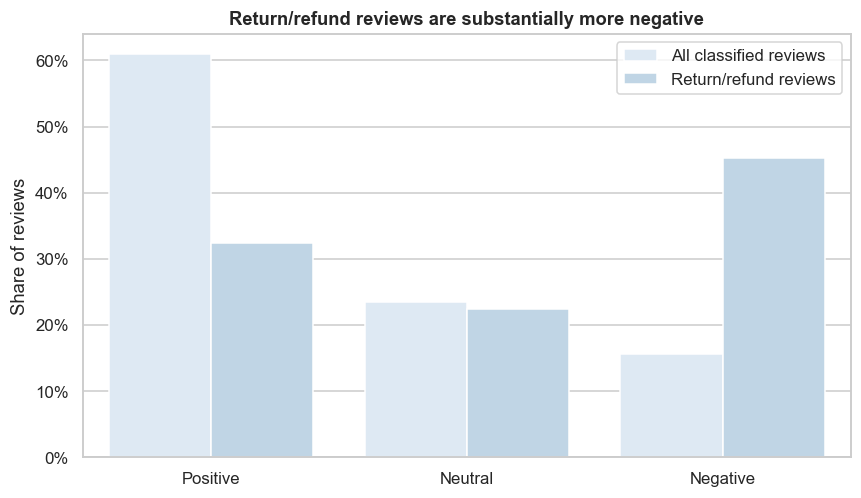

,reviewed_orders,mean_score,median_score,low_score_rate,high_score_rate
return_signal,,,,,
All other orders,97659,4.11,5.0,13.9%,77.2%
Return/refund signal,1014,1.74,1.0,76.1%,10.6%


In [4]:
sentiment_order = ['Positive', 'Neutral', 'Negative']
sentiment_compare = (
    pd.concat([
        reviews.assign(group='All classified reviews'),
        return_reviews.assign(group='Return/refund reviews')
    ])
    .groupby(['group', 'sentiment']).size().rename('count').reset_index()
)
sentiment_compare['share'] = sentiment_compare.groupby('group')['count'].transform(lambda s: s / s.sum())

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=sentiment_compare, x='sentiment', y='share', hue='group', order=sentiment_order, ax=ax)
ax.yaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')
ax.set(title='Return/refund reviews are substantially more negative', xlabel='', ylabel='Share of reviews')
ax.legend(title='')
plt.show()

score_summary = (
    order_frame.groupby('return_signal')['review_score']
    .agg(reviewed_orders='count', mean_score='mean', median_score='median',
         low_score_rate=lambda s: s.le(2).mean(), high_score_rate=lambda s: s.ge(4).mean())
    .rename(index={False: 'All other orders', True: 'Return/refund signal'})
)
display(score_summary.style.format({'mean_score': '{:.2f}', 'median_score': '{:.1f}',
                                     'low_score_rate': '{:.1%}', 'high_score_rate': '{:.1%}'}))

## 2. Order status and delivery context

`delivery_delay_days > 0` means delivery after the estimated date. Delivery metrics below include delivered orders with usable timestamps only.

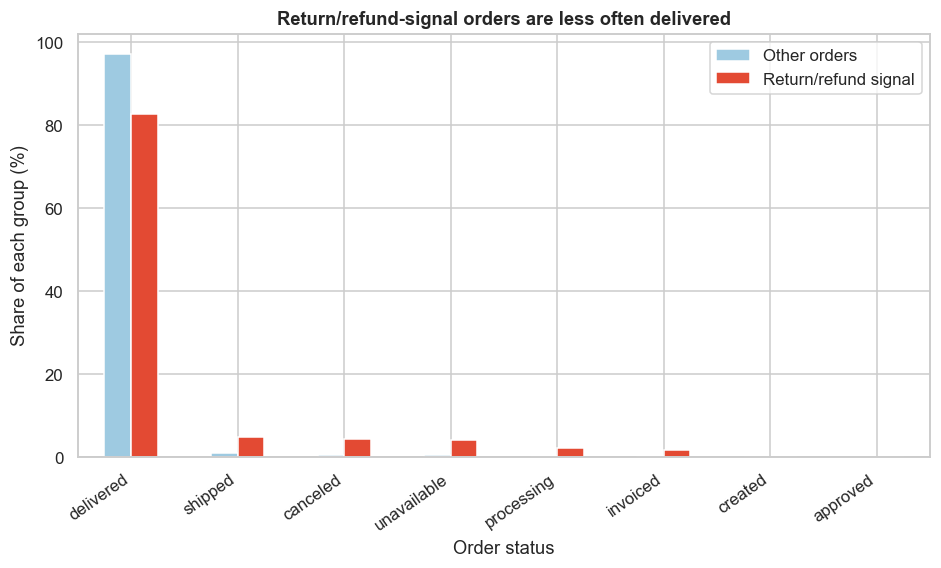

,orders,late_rate,avg_delay_days,median_delay_days,avg_delivery_days
return_signal,,,,,
All other delivered orders,95633,6.7%,-11.89,-12.0,12.07
Return/refund signal,837,11.8%,-10.32,-11.0,14.33


In [5]:
status = pd.crosstab(order_frame['order_status'], order_frame['return_signal'], normalize='columns').mul(100)
status.columns = ['Other orders', 'Return/refund signal']
status = status.sort_values('Return/refund signal', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
status.plot(kind='bar', ax=ax, color=['#9ecae1', '#e34a33'])
ax.set(title='Return/refund-signal orders are less often delivered', xlabel='Order status', ylabel='Share of each group (%)')
ax.legend(title='')
plt.xticks(rotation=35, ha='right')
plt.show()

delivered = order_frame.loc[order_frame['order_status'].eq('delivered') & order_frame['actual_delivery_days'].notna()].copy()
delivery_summary = (
    delivered.groupby('return_signal')
    .agg(orders=('order_id', 'size'), late_rate=('late_delivery_flag', 'mean'),
         avg_delay_days=('delivery_delay_days', 'mean'), median_delay_days=('delivery_delay_days', 'median'),
         avg_delivery_days=('actual_delivery_days', 'mean'))
    .rename(index={False: 'All other delivered orders', True: 'Return/refund signal'})
)
display(delivery_summary.style.format({'late_rate': '{:.1%}', 'avg_delay_days': '{:.2f}',
                                       'median_delay_days': '{:.1f}', 'avg_delivery_days': '{:.2f}'}))

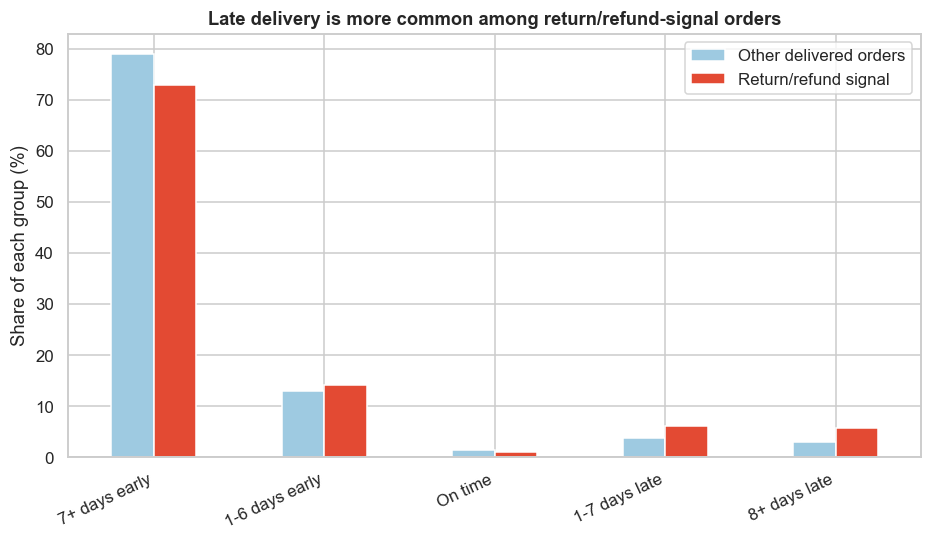

In [6]:
delay_bins = [-np.inf, -7, -1, 0, 7, np.inf]
delay_labels = ['7+ days early', '1-6 days early', 'On time', '1-7 days late', '8+ days late']
delivered['delay_band'] = pd.cut(delivered['delivery_delay_days'], bins=delay_bins, labels=delay_labels)
delay_mix = pd.crosstab(delivered['delay_band'], delivered['return_signal'], normalize='columns').mul(100)
delay_mix.columns = ['Other delivered orders', 'Return/refund signal']

fig, ax = plt.subplots(figsize=(10, 5))
delay_mix.plot(kind='bar', ax=ax, color=['#9ecae1', '#e34a33'])
ax.set(title='Late delivery is more common among return/refund-signal orders', xlabel='', ylabel='Share of each group (%)')
ax.legend(title='')
plt.xticks(rotation=25, ha='right')
plt.show()

## Key takeaways

The narrative below is generated from this notebook's focused analysis.

In [7]:
rr_negative_rate = return_reviews['sentiment'].eq('Negative').mean()
all_negative_rate = reviews['sentiment'].eq('Negative').mean()
rr_score = score_summary.loc['Return/refund signal', 'mean_score']
other_score = score_summary.loc['All other orders', 'mean_score']
rr_low_score = score_summary.loc['Return/refund signal', 'low_score_rate']
rr_delivered = status.loc['delivered', 'Return/refund signal'] / 100
other_delivered = status.loc['delivered', 'Other orders'] / 100
rr_late = delivery_summary.loc['Return/refund signal', 'late_rate']
other_late = delivery_summary.loc['All other delivered orders', 'late_rate']

summary = f'''
- **High severity:** {rr_negative_rate:.1%} of return/refund reviews are negative, compared with {all_negative_rate:.1%} across all classified reviews.
- **Very poor satisfaction:** linked return/refund-signal orders average **{rr_score:.2f}/5**, versus **{other_score:.2f}/5** for other orders; **{rr_low_score:.1%}** receive a 1- or 2-star score.
- **Pre-delivery risk matters:** only **{rr_delivered:.1%}** of signal orders are delivered, versus **{other_delivered:.1%}** of other orders. This supports proactive cancellation/refund communication for unavailable or stalled orders.
- **Delivery is an added risk:** among delivered orders, late delivery occurs for **{rr_late:.1%}** of the signal group versus **{other_late:.1%}** of others.
'''
display(Markdown(summary))


- **High severity:** 45.2% of return/refund reviews are negative, compared with 15.6% across all classified reviews.
- **Very poor satisfaction:** linked return/refund-signal orders average **1.74/5**, versus **4.11/5** for other orders; **76.1%** receive a 1- or 2-star score.
- **Pre-delivery risk matters:** only **82.5%** of signal orders are delivered, versus **97.2%** of other orders. This supports proactive cancellation/refund communication for unavailable or stalled orders.
- **Delivery is an added risk:** among delivered orders, late delivery occurs for **11.8%** of the signal group versus **6.7%** of others.
